# WETH/USDC Realistic Simulator

**Goal:** an end-to-end simulator of the Uniswap V3 5bp WETH/USDC pool whose retail outcomes match on-chain reality.

**Structure.** §1 and §2 show that the realistic simulator's *primitives* (price returns, retail order arrivals and sizes) match the empirical distributions where the Simple AMM Challenge defaults don't. §3 introduces the two-pool architecture. §4 calibrates the one free piece of that architecture — the V2 *normalizer pool* that represents the rest of the market — against the realized non-5bp retail impact curve. §5 validates the calibration against retail-only outcomes on the 5bp pool, which never feed into the fit. §6 reads the validation. §7 discusses how much further we should purify the retail cohort and how much residual contamination is acceptable for each downstream use.


In [1]:
import sys, os, importlib

# Add project root and presentation dir to path
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, _nb_dir)
sys.path.insert(0, os.path.dirname(_nb_dir))

# Reload helpers so re-running this cell picks up edits without a kernel restart.
import helpers
importlib.reload(helpers)
from helpers import *
%matplotlib inline

---
## Section 1: Return Distributions

The Simple AMM Challenge uses a **Geometric Brownian Motion** (GBM) model for price returns. Real ETH/USD returns (measured from Binance order book at 12-second intervals) exhibit heavier tails and regime-dependent volatility that GBM cannot capture.

Our realistic simulator uses a **5-regime Markov-switching process** fitted to empirical return quantiles.

In [2]:
observed_90d = load_binance_quantiles("90d")
challenge_rets = generate_challenge_return_quantiles()
realistic_rets = generate_realistic_return_quantiles()

### Chart 1a: Challenge (GBM) vs Observed Returns

The GBM model is too concentrated around zero — it underestimates the probability of large price moves.

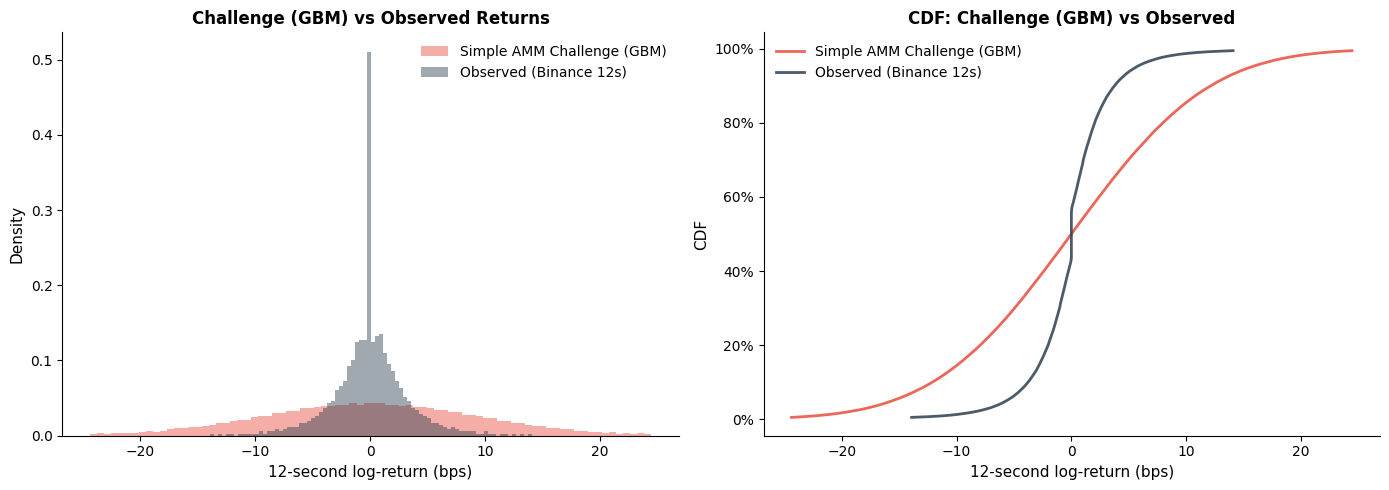

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="Challenge (GBM) vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(challenge_rets, "challenge"), (observed_90d, "observed")],
    title="CDF: Challenge (GBM) vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 1b: Realistic Simulator vs Observed Returns

The regime-switching model closely tracks the empirical distribution, including the heavy tails.

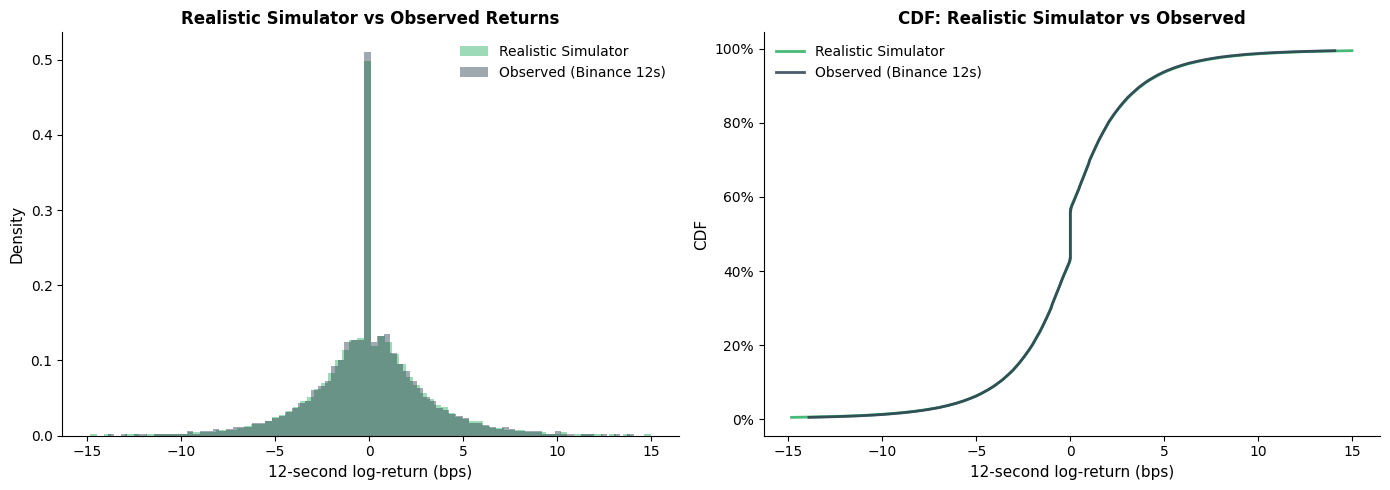

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_return_hist_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="Realistic Simulator vs Observed Returns",
    ax=ax1,
)
plot_return_cdf_overlay(
    [(realistic_rets, "realistic"), (observed_90d, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Robustness: Consistent Across Lookback Windows

The observed distribution is stable across 90-day, 180-day, and 360-day windows.

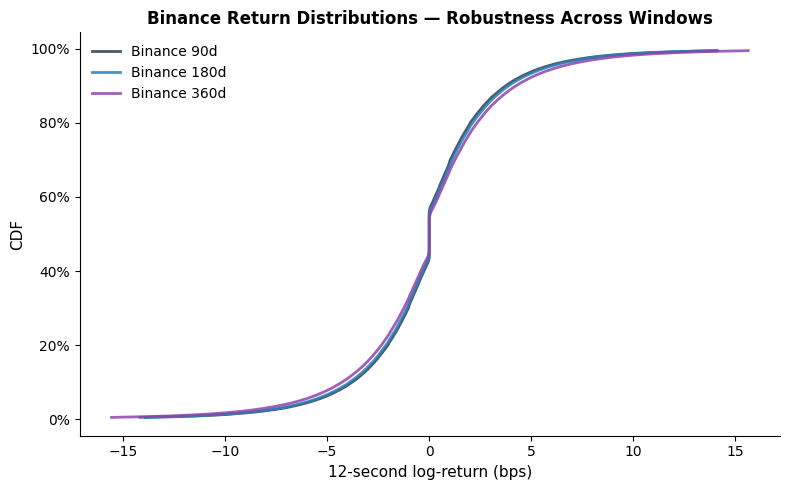

In [5]:
plot_return_robustness()
plt.tight_layout()
plt.show()

---
## Section 2: Retail Order Arrival & Size Distribution

The Challenge uses a **Poisson process** (rate=0.8/block) with **lognormal order sizes** (mean ≈ $20, σ = 1.2). Real retail flow looks nothing like that. We now measure it on the **same strict-retail cohort used for calibration (§4) and validation (§5)** — transactions from a known end-user front-end: the **Uniswap first-party app** (web / mobile / extension, via the `core.swaps` surface tag) ∪ **MetaMask Swaps** (87.5 bps fee) — over the 30-day window 2026-04-21..05-20.

Our realistic simulator samples **USD order sizes directly** from this strict empirical parent-order distribution, at the observed strict arrival rate (**~0.46/block**: 98,676 parent orders / 216,000 blocks). The broad 19-router cohort (~0.66/block) is retained for robustness checks but is no longer the primary sample.

### Chart 2a: Arrival Rates

The realistic simulator's arrival rate (~0.46/block) is matched to the observed strict-retail rate by construction. The Challenge's fixed 0.8/block is calibrated to nothing in particular and overstates strict-retail arrivals by ~75%.

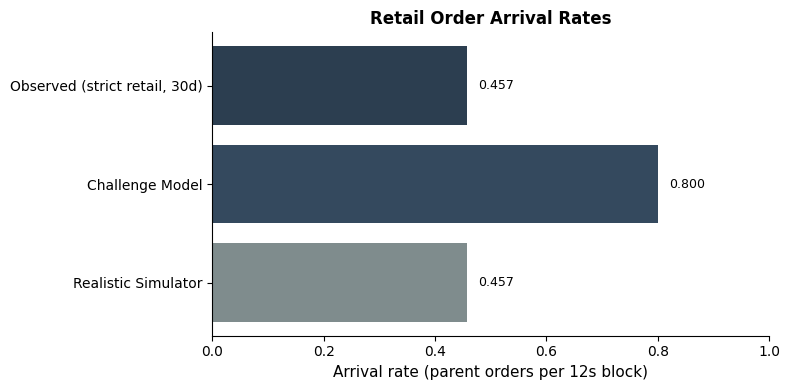

In [6]:
plot_arrival_rate_comparison()
plt.tight_layout()
plt.show()

In [7]:
observed_retail = load_strict_retail_quantiles()
challenge_retail = generate_challenge_retail_quantiles()
realistic_retail = generate_realistic_retail_quantiles()

### Chart 2b: Challenge (Lognormal) vs Observed Order Sizes

The lognormal model concentrates mass around $20 and completely misses the heavy right tail of real orders.

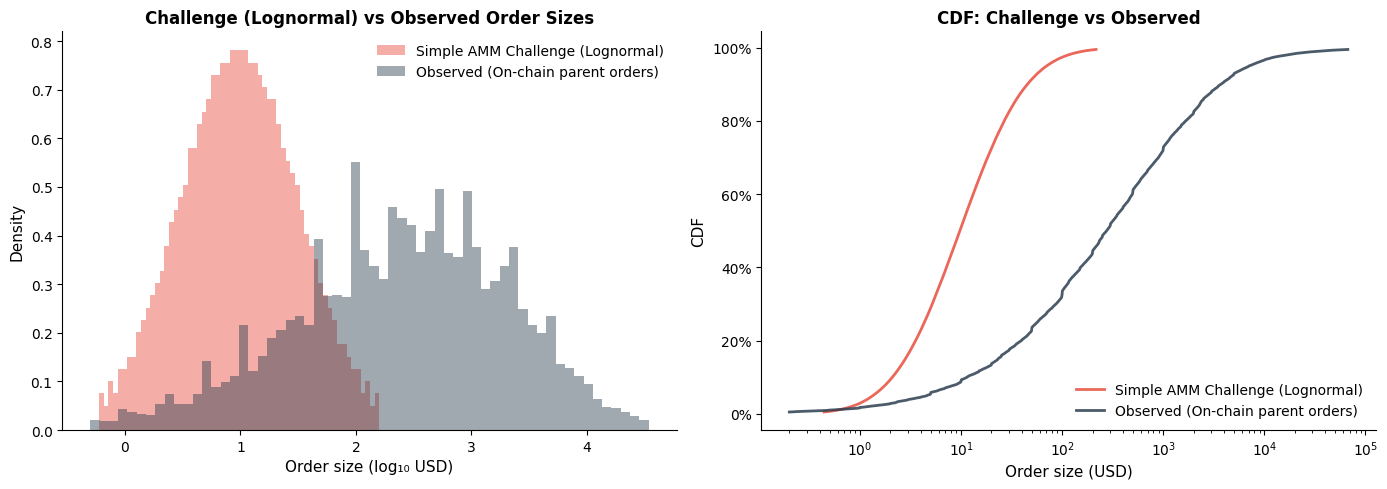

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="Challenge (Lognormal) vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(challenge_retail, "challenge"), (observed_retail, "observed")],
    title="CDF: Challenge vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

### Chart 2c: Realistic Simulator vs Observed Order Sizes

The empirical USD-size model closely matches the observed strict-retail parent-order distribution (the sim samples directly from it). Critically, the strict cohort's size tail tops out near **$1.4M — no multi-million-dollar whale trades** — which is what fixes the LP-markout overshoot seen with the broad cohort (see §6).

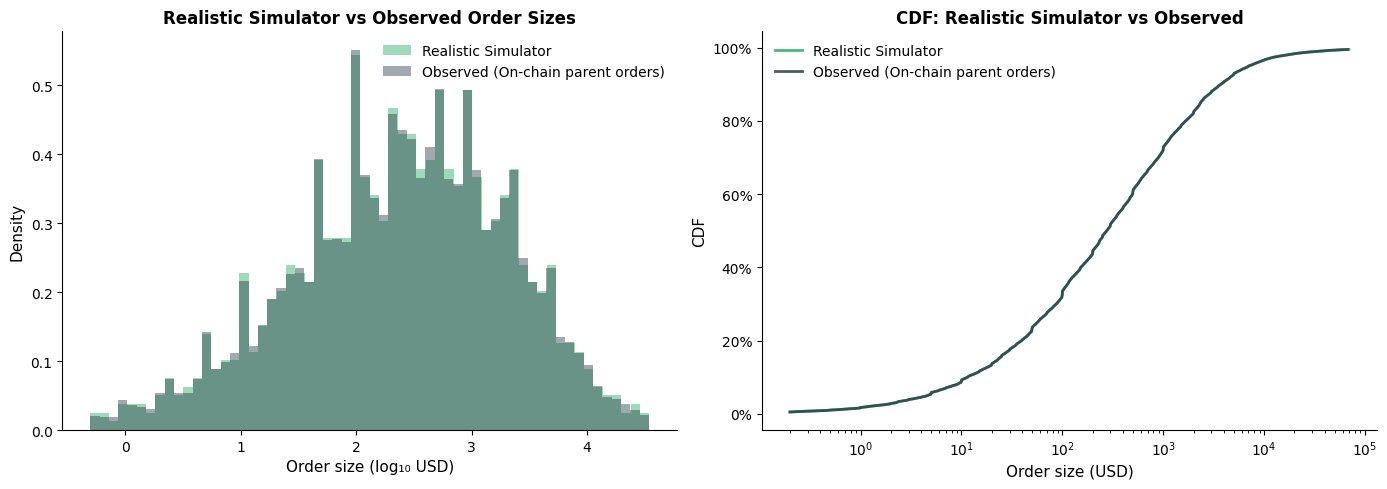

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_retail_hist_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="Realistic Simulator vs Observed Order Sizes",
    ax=ax1,
)
plot_retail_cdf_overlay(
    [(realistic_retail, "realistic"), (observed_retail, "observed")],
    title="CDF: Realistic Simulator vs Observed",
    ax=ax2,
)
fig.tight_layout()
plt.show()

---
## Section 3: Two-pool architecture

The simulator models the WETH/USDC market as two pools:

- **Submission pool.** The real Uniswap V3 5bp pool, **frozen** at its on-chain configuration: `fee = 5 bps`, `virtual_depth_y = $212.16M` USDC. No free parameters. Arbitrageurs trade against it each step to pull its mid toward the prevailing fair price.
- **Normalizer pool.** A single hypothetical V2 (constant-product) pool that represents *everything else* — V4 1bp + 30bp, V3 30bp, V2, Curve, Balancer, etc. Two free parameters: spread **φ** (proportional fee) and depth **D** (USDC-side).

**The normalizer is held at fair, not arbed.** At the top of every step the normalizer's mid is re-synced directly to the current fair price at constant USDC depth `D` (`reserve_y = D`, `reserve_x = D/fair`). It therefore represents the *efficient* rest-of-market — always correctly priced the instant retail arrives — and **no arbitrage ever hits it**. (Previously the normalizer was a live pool dragged toward fair by a per-step arb; that left it slightly stale between arbs and made its price depend on arb timing. Snapping it to fair removes both artifacts.) Only the 5bp submission pool is arbitraged.

Each retail order is **split across both pools to equalize their marginal execution price** (the closed-form two-AMM optimal split in `OrderRouter.split_buy/sell_two_amms`) — not routed wholesale to a single venue. The deeper / cheaper pool simply receives the larger share. The normalizer's `(φ, D)` is the only thing we calibrate.

---
## Section 4: Calibrating the normalizer pool

**Target.** The empirical price-impact curve of **strictly-retail** transactions on **non-5bp** WETH/USDC pools, referenced against the **prevailing fair price one 12s step before the trade** (the real-data analog of the simulator's "1 step before"). For each tx we measure:
- `size_usd` — total USD traded across the tx's non-5bp legs
- `spread_bps` — `1e4 × (effective_price − fair_lag) × side / fair_lag`, where `fair_lag` is the fair price at or before 12s before the trade.

**Why a strict-retail filter.** The normalizer pool exists to be a realistic *retail* competitor to the submission pool — the question it answers is how retail order routing reacts to changes in the new pool. So it is calibrated to flow that is unambiguously human retail on a known front-end, not the broad router-level superset (which mixes in MM execution, arb bots, and aggregator flow). The cohort is the **union of two front-end sources**:
- **Uniswap first-party front-end** (web app + mobile wallet + extension) — from `uniswap-labs.core.swaps`, which materializes the off-chain `x-request-source` surface tag and the tx hash. There is *no* on-chain marker for interface flow (Uniswap dropped the web/mobile swap fee at UNIfication 2025-12-27, and web/mobile build byte-identical calldata), so this internal surface attribution, joined by tx hash, is the only clean signal. It is the dominant retail source (~66K of the non-5bp WETH/USDC txs).
- **MetaMask Swaps** — txs that paid the **87.5 bps** convenience fee to `0xf326e4…f1915` (Etherscan "MetaMask: DS Proxy"; ~87.9 bps empirically), ~3.8K txs.

The two surfaces are disjoint (zero tx overlap). A 25 bps collector `0xcd6b98…` that initially looked like a Uniswap interface fee turned out to be **Rabby Wallet**, not Uniswap, and is excluded.

**Why lagged fair (not pool mid, not contemporaneous fair).** This matches the normalizer's role in §3: retail trades against a pool sitting at the prevailing fair, so we calibrate impact *relative to fair*. We use a **pre-trade** fair (one 12s step stale) so the reference cannot have been moved by the trade's own impact. The cost is noise — each trade's spread also carries ~12s of price drift — so the USD-weighted **Huber** loss (Plan B) is the robust default. The sample CSV still carries the pool-mid and contemporaneous-fair spreads as diagnostics.

**Fair-price source.** The Binance book table only covers 2023-04..2025-11, so the fair series is reconstructed from `markout_prod.benchmark` over all WETH/USDC swaps (last observation per 12s bucket, forward-filled), and each trade reads the bucket immediately preceding its own. See `analysis/weth_usdc_90d/sql/non5bp_impact_sample_v3_pool_mid_7d.sql`.

**Universe & window.** Uniswap V3 non-5bp WETH/USDC swap legs (V3 ≈ 90% of non-5bp volume), aggregated per tx, restricted to the strict-retail cohort, over a **30-day window (2026-04-21..2026-05-20)**: **~70K transactions**. The retail trades span up to ~$350K (median ~$430; 18 trades ≥ $100K, **none ≥ $1M** — no whales), wide enough that the impact slope is clearly visible, so **both φ and depth D are well-identified** — Plan A (L2) and Plan B (Huber) independently agree on D ≈ $64M. (Contrast the MetaMask-only interim cohort, which topped out at ~$36K and left D only loosely pinned.)

**Model.** A V2 constant-product pool with fee φ and depth D has retail-side spread

$$\text{spread} = \frac{\varphi + (1-\varphi)\,S/D}{1-\varphi}\,.$$

**Loss.** USD-weighted Huber on residual spread (`scripts/calibration/fit_impact_curve_pool_mid.py`, Plan B; δ = 90th percentile of |residual| under the USD-weighted-L2 Plan A). We default to Plan B below.

In [10]:
fit = load_impact_curve_fit()
phi_b   = fit['plan_b']['phi']
depth_b = fit['plan_b']['depth_usdc']
print(f"Plan B fit")
print(f"  φ      = {phi_b*1e4:.3f} bps")
print(f"  depth  = ${depth_b/1e6:,.1f}M USDC")
print(f"  n_txs  = {fit['n_txs']:,}")
print(f"  window = {fit['window']}")


Plan B fit
  φ      = 2.182 bps
  depth  = $63.9M USDC
  n_txs  = 69,627
  window = 2026-04-21..2026-05-20


### Chart 3a: Empirical impact curve + V2 fit


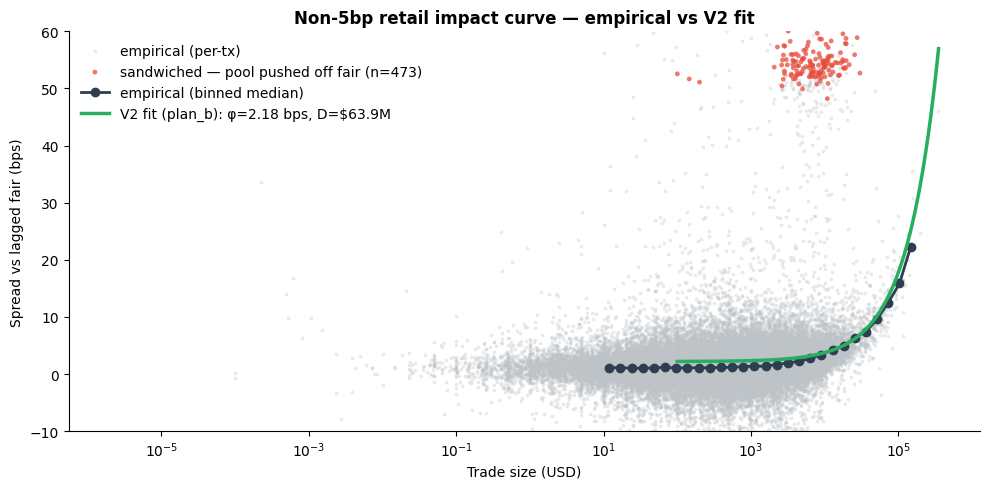

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_impact_curve_fit(ax=ax, plan_key='plan_b')
plt.tight_layout()
plt.show()


**Red dots — sandwiched trades (flagged sample-wide, not removed from the fit).**

Red marks trades that filled against a pool whose **pre-trade mid was already pushed off fair** — the on-chain sandwich / transient-MEV-excursion signature. Verified on same-block traces: a *separate* frontrun tx earlier in the block pushes the pool 10–68% off fair, the retail trade fills at that pushed price, and a backrun restores the pool within the same block. (This is why these trades look cheap vs the pool's own pre-trade mid — `pool_mid_pre` = the frontrun's price — but expensive vs an external CEX fair.)

**Rule** — applied to every trade in the sample (not just the visible cluster). A trade is flagged *sandwiched* when:

```
|pool_mid_pre_blended / fair_price_blended − 1| > 0.5%   AND   |observed_spread_pool_bps| < 20 bps
```

i.e. the pool's pre-trade mid sat more than 0.5% (50 bps) from the contemporaneous fair, while the fill itself executed within 20 bps of that pushed mid — a *victim* of the push, not a trade that moved the pool with its own size. This flags **473 of ~70K** trades (mostly the 1bp pool `0xe0554a…`, largely memecoin multi-hop routes that touch WETH/USDC as a hop).

These are **MEV slippage, not the pool's mechanical impact**, which is why they sit above the V2 fit. They are a **visual call-out only** — the fitted `(φ, D)` and the binned-median curve are computed on the full sample, unchanged. To exclude them from a future *mechanical*-impact recalibration, the same predicate drops straight into the fit's row filter.

---
## Section 5: Held-out retail validation

We now run the simulator with the calibrated normalizer and the frozen 5bp submission pool, and compare three **retail-only** outcomes against on-chain reality. Crucially, none of these metrics fed into the fit — they are genuinely held out.

We focus on retail because the arb side carries no free parameters: only the 5bp submission pool is arbitraged (the normalizer is held at fair by construction, §3), and that arb is closed-form and deterministic. The retail-side metrics carry the signal about whether the normalizer pool's `(φ, D)` is correct.

**Metrics**
1. **Retail volume share at 5bp** = `retail_vol_5bp / retail_vol_total`.
2. **Retail fee share at 5bp**    = `retail_fees_5bp / retail_fees_total`.
3. **USD-weighted retail markout_15s distribution** at the 5bp pool. Convention: `markout_15s` for LP profitability (15 seconds is the standard horizon); USD-weighted percentiles emphasize the large trades that drive LP P&L.

**Real numbers** are pulled from `dex_trades` (volume + fees) and `markout_prod` (per-swap markouts) over the same 30-day window, on the **same strict-retail cohort** (Uniswap first-party FE ∪ MetaMask) used for calibration and the size distribution — so sim and real describe the identical population (the symmetry §7 argues for). See `sql/retail_5bp_share_strict_30d.sql` and `sql/markout_5bp_pool_strict_30d.sql`. (The broad 19-router builders are kept for robustness.)

**Sim numbers** are produced by `scripts/calibration/validate_pool_mid.py` with five seeds × 5,000 steps. Per-trade sim markouts use the next-block `fair_price` (~12s — closest available proxy for the 15s real reference).

In [12]:
validation = load_validation()
get_validation_summary_table()


,Metric,Real (on-chain),Simulator
0,Retail volume share @5bp,45.89%,48.90% ± 1.56pp
1,Retail fee share @5bp,17.36%,68.66% ± 1.35pp
2,Retail markout_15s — USD-w mean,+9.71 bps,+5.28 bps
3,Normalizer φ,—,2.18 bps
4,Normalizer depth,—,$63.9M
5,Submission pool fee,5.00 bps (frozen),5.00 bps (frozen)
6,Submission pool depth,$212.2M (frozen),$212.2M (frozen)


### Chart 5a: Retail volume / fee share at 5bp pool


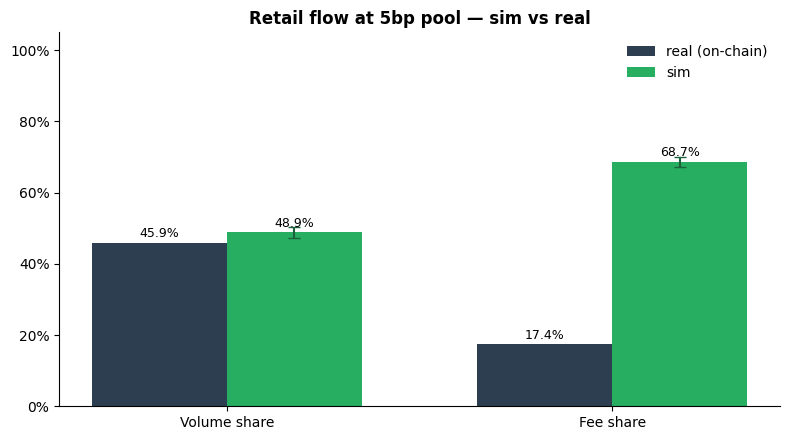

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_retail_share_bars(ax=ax)
plt.tight_layout()
plt.show()


### Chart 5b: Retail markout_15s on 5bp pool — USD-weighted


/Users/xinwan/Github/amm-gym/presentation/helpers.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, frameon=False)


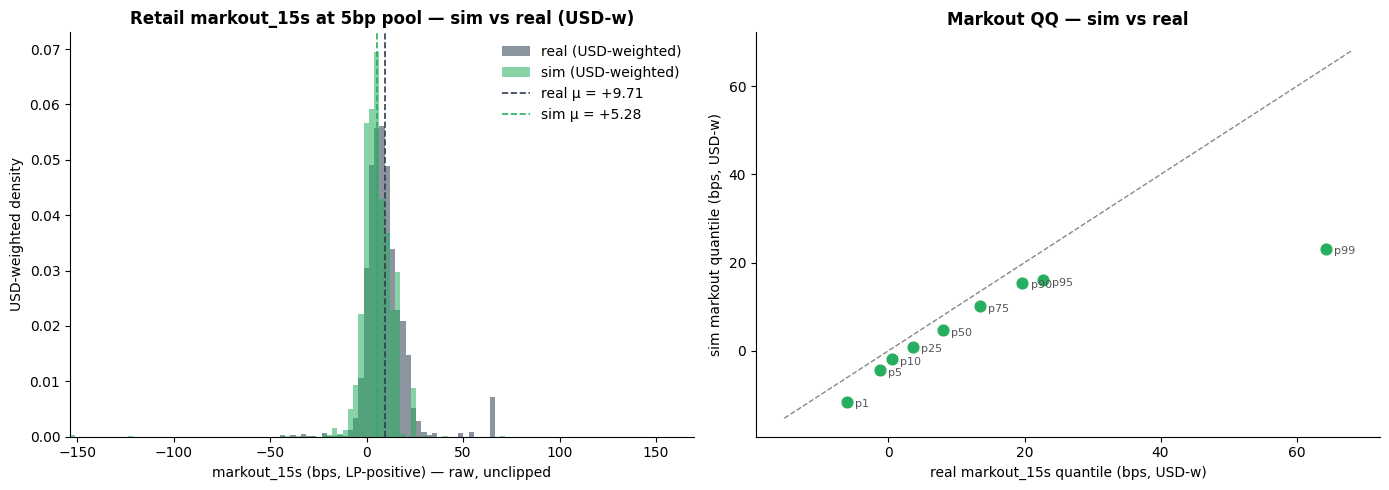

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_retail_markout_overlay(ax=ax1)
plot_retail_markout_qq(ax=ax2)
plt.tight_layout()
plt.show()


---
## Section 6: Reading the validation

**Caveat on the real-world numbers.** This is the *cleaned, strict-retail* validation. An earlier version included two Wintermute MM contracts in the retail-router list; with them in, retail volume share at 5bp looked like 78% and markout like −3 bps, and the sim spuriously "matched." After the router cleanup — and now a further shift of **all three samples (size distribution §2, calibration §4, validation §5) onto a single strict end-user front-end cohort** (Uniswap first-party FE via `core.swaps` ∪ MetaMask 87.5bps fee, 30d) — sim and real describe the *identical* population. This is the symmetric, apples-to-apples setup §7 argues for. (The broad 19-router method is kept for robustness.)

**How the model is specified now.**
1. **Normalizer held at fair, not arbed (§3)** — snapped to current-step fair at constant depth `D`; no arb touches it.
2. **Calibrated to lagged pre-trade fair on strict-retail non-5bp flow (§4)** — φ = 2.18 bps, D = $63.9M, both well-identified.
3. **Size distribution, arrival rate, buy share, and validation targets all on the same strict cohort** — arrival ~0.46/block, buy share 0.46, size tail topping out near $1.4M (no whales).

**Volume share — close.** Strict real retail routes ~45.9% of WETH/USDC flow to the 5bp pool; the sim routes **~48.9%** (Δ +3.0 pp). The residual reflects the normalizer's φ ≈ 2.2 bps making the 5bp pool slightly more attractive than reality.

**Markout — now resolved.** This was the headline gap. Strict real USD-weighted retail markout_15s is **+9.7 bps**; the sim now shows **+5.3 bps** (Δ −4.4 pp), down from +58 bps under the broad size distribution. The fix was Purpose-A purity (§7): the strict size distribution produces **0 sim trades ≥ $1M** (max ~$373K at the 5bp pool), vs the broad cohort's $5M whale trades that each marked out ~+250 bps on mechanical impact. With no synthetic whales the sim no longer overstates LP profit; it now slightly *undershoots* real markout, consistent with real strict-retail being marginally more profitable to the LP than the uninformed sim flow. (The single biggest LP-losing trade in the old broad cohort — a $524K, −9.4 bps fill — was a known MM's cross-asset hedge, not retail; dropping such contamination is part of why strict real markout rose to +9.7.)

**Fee share — still fails large.** Strict real retail pays only ~17% of its WETH/USDC fees at the 5bp pool; the sim produces **~69%**. A single low-φ V2 normalizer collects negligible fees and cannot match the empirical fee mix of the heterogeneous non-5bp universe (V4 30bp, V3 30bp, Curve, …). This is the **one binding model-misspecification** that survives the cohort cleanup.

**Takeaway.** On the symmetric strict-retail cohort the simulator matches real retail on volume share (within ~3 pp) and markout (within ~4 bps). The lone remaining gap is fee share, which is structural — a single V2 normalizer can't reproduce the fee mix of the many non-5bp venues. The higher-leverage next steps are a multi-tier normalizer (for fee share) and retail-flow-informed price drift (for the residual markout sign), not further cohort filtering.

---
## Section 7: Retail-sample robustness

All three uses of real retail data — the size distribution (§2), the calibration (§4), and the validation (§5) — now sit on **one cohort**: transactions from a known end-user front-end (Uniswap first-party app via the `core.swaps` surface tag ∪ MetaMask Swaps' 87.5 bps fee). Calibrating, sizing, and validating on the *same* population is what makes the comparison apples-to-apples. (An earlier per-transaction audit confirmed the broad 19-router cohort mixes in MM / whale / arb flow. The size distribution is the use most sensitive to that contamination — it's why the strict shift collapsed the sim markout from +58 to +5 bps — while the impact-curve calibration is the least sensitive, since AMM mechanics don't depend on trader identity.)

**The catch: the strict cohort is a _subset_ of true retail.** It captures only two front-ends, so it almost certainly **understates the arrival rate**, and its size tail (capped ~$1.4M) is thinner than the broad cohort's (~$7M) — we likely **understate large-order frequency** too. The true distribution is unknown, and chasing it is a rabbit hole.

So rather than pick a single "best" sample, treat the retail assumption as a **dial**. We anchor on the strict cohort (conservative) and the broad 19-router cohort (aggressive) and interpolate the arrival rate and order-size quantiles between them. The sweep below shows how the validation metrics move across that range; the slider lets you set the assumption yourself and re-run the sim.

**Takeaway.** Volume share and especially markout are sensitive to the retail-size assumption — markout ranges from ~+5 bps (conservative) to ~+80 bps (aggressive) as the size tail fattens — so read the sim's absolute markout as a *band*, not a point. **Fee share stays ~68–75% across the whole range**: that's a structural normalizer-fee-mix gap, not a sampling artifact, and it's the one conclusion that holds regardless of where you set the dial.

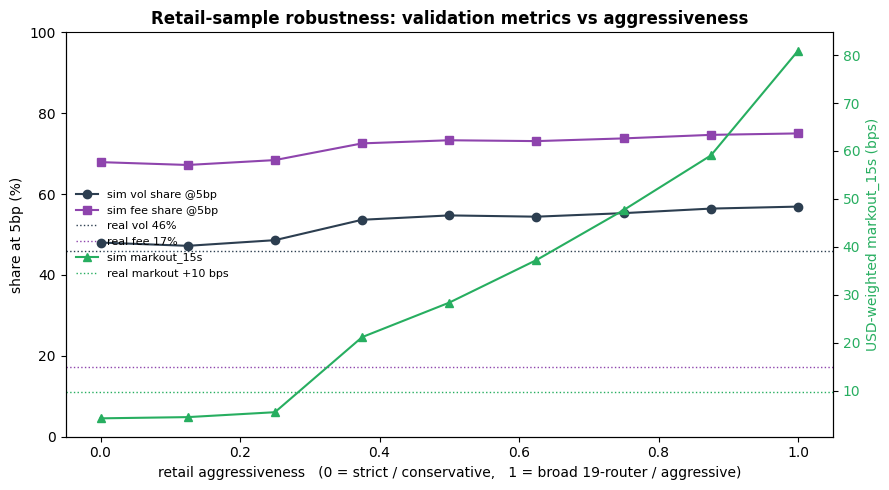

In [15]:
# Sweep the retail assumption from strict/conservative (0) to broad/aggressive (1).
# Re-runs the validation sim at each anchor; ~10-15s.
fig, ax = plt.subplots(figsize=(9, 5))
plot_retail_robustness_sweep(ax=ax)
plt.tight_layout()
plt.show()

In [16]:
# Interactive (JupyterLab): drag to set how aggressive vs conservative the retail
# assumption is (arrival rate + order-size tail); the sim re-runs and reports the
# validation metrics. Static export shows the conservative (strict) end.
retail_robustness_slider()

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='aggressiveness', layout=Lay…